# EDA — Yield Patterns

Goal: identify sensor-level signals that separate passing from failing wafers and select candidate sensors to watch before SHAP modeling (global rankings in `src/yield_risk/explainability.py` and sensor ranking analysis in `src/yield_risk/root_cause.py`). The analysis loads the raw training split from `data/splits/`, applies the same preprocessing the model pipeline uses (`SecomPreprocessor`, fit on the training split), then computes point-biserial correlations between every retained sensor and the binary fail label, plots distributions for the highest-signal sensors, and closes with concrete predictions about which sensors should surface as important in later SHAP and ranking analysis.

Scope note: every statistic below is computed on the training split only — the test set stays sealed until the single final model evaluation — so the candidate sensors form a genuine pre-modeling hypothesis to check against the later SHAP and ranking results, not a description that has already seen the held-out data.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pointbiserialr

from yield_risk.config import load_config
from yield_risk.preprocess import SecomPreprocessor

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
SPLITS_DIR: Path = Path("../data/splits")
cfg = load_config(Path("..") / "configs" / "config.yaml")

# Training split only: the test set stays sealed until the single final model
# evaluation, so no label-dependent statistic in this notebook may see it.
train_raw: pd.DataFrame = pd.read_csv(SPLITS_DIR / "train.csv")

raw_sensor_cols: list[str] = [c for c in train_raw.columns if c.startswith("sensor_")]

# Reconstruct the feature matrix the model actually sees: fit the preprocessor
# on the training split and transform it.
preprocessor = SecomPreprocessor(
    missing_threshold=cfg.run.missing_threshold,
    cv_threshold=cfg.run.cv_threshold,
    correlation_threshold=cfg.run.correlation_threshold,
).fit(train_raw[raw_sensor_cols])

df: pd.DataFrame = preprocessor.transform(train_raw[raw_sensor_cols]).assign(
    label=train_raw["label"].to_numpy()
)

SENSOR_COLS: list[str] = list(preprocessor.get_feature_names_out())
TARGET: pd.Series = df["label"]

print(f"Rows: {len(df)}  |  Sensors: {len(SENSOR_COLS)}  |  Fail rate: {TARGET.mean():.1%}")
df[SENSOR_COLS + ["label"]].head()

Rows: 1331  |  Sensors: 242  |  Fail rate: 6.6%


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_006,sensor_007,sensor_008,sensor_009,sensor_010,...,sensor_560,sensor_570,sensor_571,sensor_572,sensor_573,sensor_583,sensor_586,sensor_587,sensor_589,label
0,2991.74,2575.39,2173.6444,1458.7176,0.8811,101.5667,0.1258,1.5514,-0.0275,-0.0001,...,0.0308,539.0582,2.0084,5.4100,0.2516,0.0184,0.0331,0.0210,63.2615,0
1,2960.04,2292.40,2215.3889,1779.1892,0.8552,101.2178,0.1226,1.4644,0.0049,-0.0020,...,0.0332,530.7909,2.0698,10.5500,0.2194,0.0119,0.0154,0.0113,73.6411,0
2,2945.90,2539.58,2227.2444,1129.8739,1.2803,102.7956,0.1188,1.5401,0.0036,-0.0036,...,0.1157,530.9809,2.3259,9.9400,0.2182,0.0086,0.0052,0.0203,390.4146,0
3,2943.76,2481.99,2190.7666,3530.2362,0.8017,83.8767,0.1249,1.3214,0.0009,-0.0074,...,0.0509,536.0709,2.1472,8.3701,0.2640,0.0135,0.0115,0.0142,122.9917,0
4,2917.17,2379.31,2215.3889,1779.1892,0.8552,101.2178,0.1226,1.4643,0.0047,0.0039,...,0.0399,532.2100,2.2089,8.2200,0.3725,0.0091,0.0154,0.0113,73.6411,0


## 1  Point-biserial correlation

**Question:** Which sensors have the strongest linear association with the binary fail label, and in which direction?

In [3]:
def compute_correlations(
    features: pd.DataFrame,
    target: pd.Series,
) -> pd.DataFrame:
    """Compute point-biserial correlation of each sensor column with a binary target.

    Args:
        features: DataFrame of continuous sensor readings. Each column is one sensor.
        target: Binary series (0 = pass, 1 = fail), index-aligned with *features*.

    Returns:
        DataFrame with columns ``sensor``, ``r``, and ``abs_r``, sorted by
        ``abs_r`` descending.
    """
    rows: list[dict[str, object]] = [
        {"sensor": col, "r": pointbiserialr(features[col], target).statistic}
        for col in features.columns
    ]
    result: pd.DataFrame = pd.DataFrame(rows)
    result["abs_r"] = result["r"].abs()
    return result.sort_values("abs_r", ascending=False).reset_index(drop=True)


corr_df: pd.DataFrame = compute_correlations(df[SENSOR_COLS], TARGET)
corr_df.head(20)

,sensor,r,abs_r
0,sensor_103,0.156123,0.156123
1,sensor_059,0.135363,0.135363
2,sensor_510,0.132647,0.132647
3,sensor_431,0.110254,0.110254
4,sensor_348,0.107286,0.107286
5,sensor_129,0.106500,0.106500
6,sensor_021,0.103741,0.103741
7,sensor_430,0.098708,0.098708
8,sensor_434,0.098441,0.098441
9,sensor_125,-0.097129,0.097129


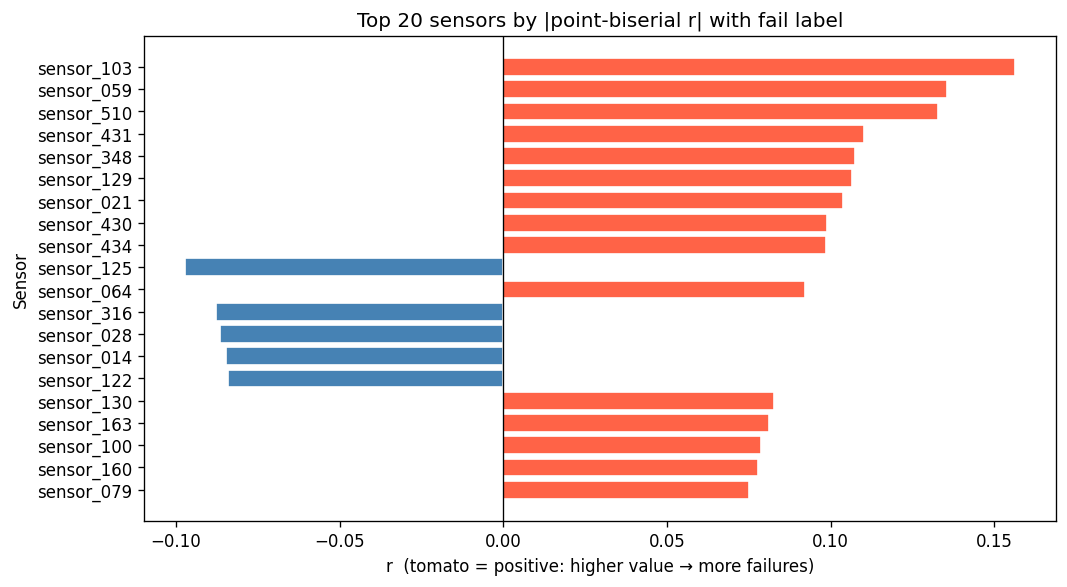

In [4]:
top20: pd.DataFrame = corr_df.head(20).copy()

fig, ax = plt.subplots(figsize=(9, 5))
colors: list[str] = ["tomato" if r > 0 else "steelblue" for r in top20["r"]]
ax.barh(
    top20["sensor"][::-1],
    top20["r"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 sensors by |point-biserial r| with fail label")
ax.set_xlabel("r  (tomato = positive: higher value → more failures)")
ax.set_ylabel("Sensor")
plt.tight_layout()

Correlations are modest throughout (max |r| ≈ 0.156 for `sensor_103`), consistent with the noisy nature of semiconductor process data. Most top sensors are positively correlated with failure — higher readings predict more failures — while a substantial group (`sensor_125`, `sensor_316`, `sensor_028`, `sensor_014`, `sensor_122`) shows the opposite direction. No single sensor dominates, which suggests later SHAP analysis will show distributed importance rather than a concentrated top-1 signal.

## 2  Sensor distributions by outcome

**Question:** Do the top-10 sensors show visually distinct pass/fail distributions, or is the separation subtle?

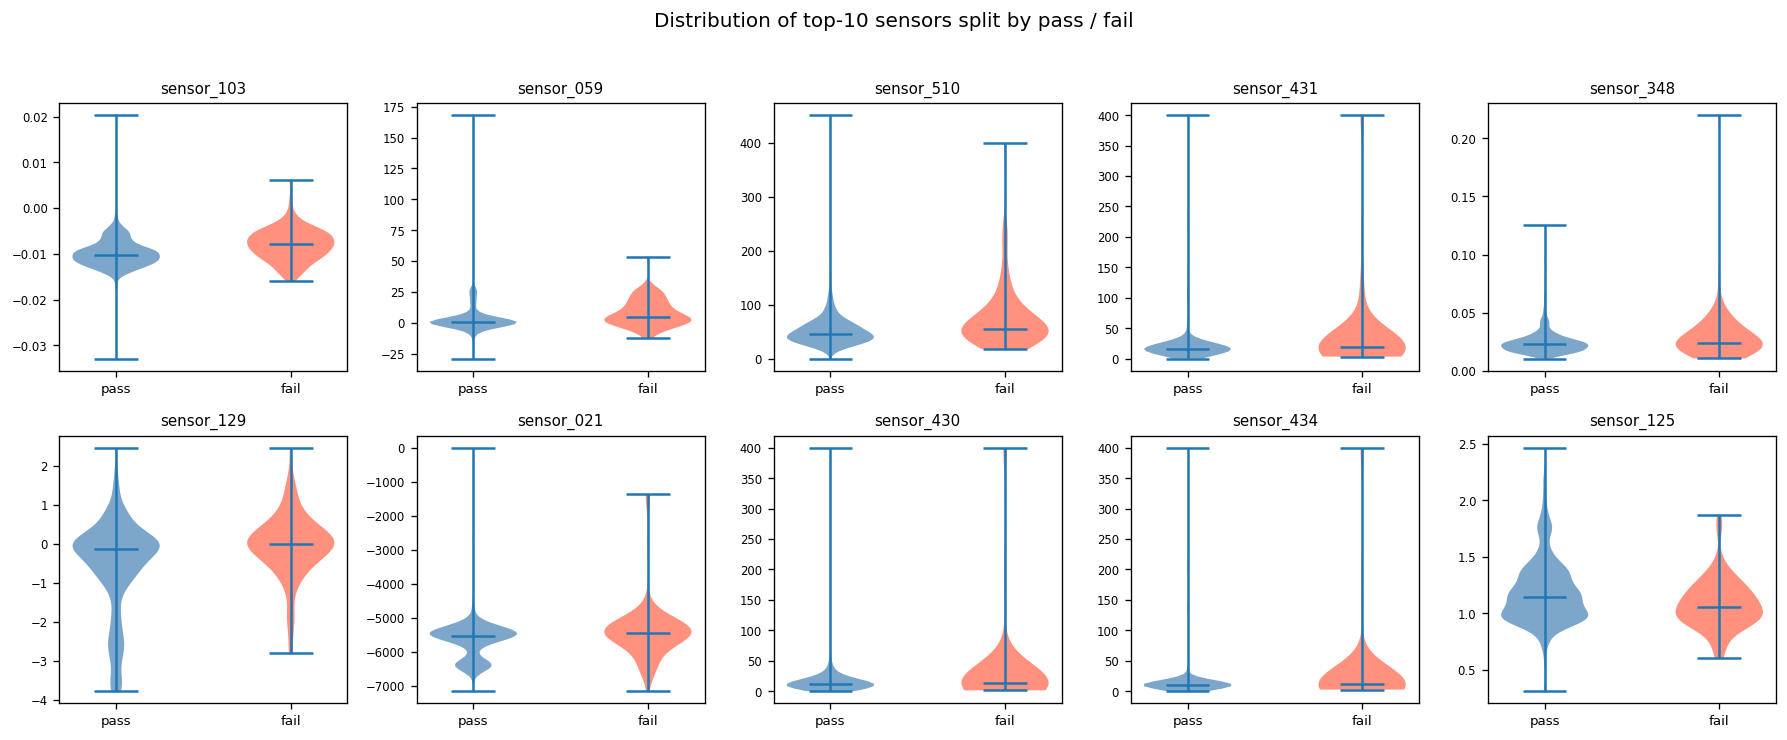

In [5]:
TOP10: list[str] = corr_df.head(10)["sensor"].tolist()

pass_df: pd.DataFrame = df[df["label"] == 0]
fail_df: pd.DataFrame = df[df["label"] == 1]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
flat_axes: list = axes.flatten().tolist()

for ax, sensor in zip(flat_axes, TOP10):
    pass_vals: np.ndarray = pass_df[sensor].dropna().values
    fail_vals: np.ndarray = fail_df[sensor].dropna().values
    parts: dict = ax.violinplot(
        [pass_vals, fail_vals],
        positions=[0, 1],
        showmedians=True,
    )
    body_colors: list[str] = ["steelblue", "tomato"]
    for body, color in zip(parts["bodies"], body_colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["pass", "fail"], fontsize=8)
    ax.set_title(sensor, fontsize=9)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Distribution of top-10 sensors split by pass / fail", y=1.02)
plt.tight_layout()

For `sensor_103`, `sensor_059`, `sensor_129`, and `sensor_510` the fail distribution is clearly shifted upward relative to pass, with minimal overlap in the upper tail — these sensors carry the most discriminative signal. For `sensor_125` (the one negatively correlated sensor in this top-10 set) the shift is downward. The remaining sensors show substantial overlap despite their moderate |r| values, reinforcing that the model must combine many weak signals.

## 3  Standardized pass/fail mean shift

Raw mean differences are not comparable across sensors — readings live on wildly different scales (some near zero, some in the thousands). Standardizing the fail−pass shift by the pooled standard deviation (Cohen's *d*) puts every sensor on one comparable axis, so a longer bar means a larger separation between the pass and fail populations regardless of the sensor's native units.

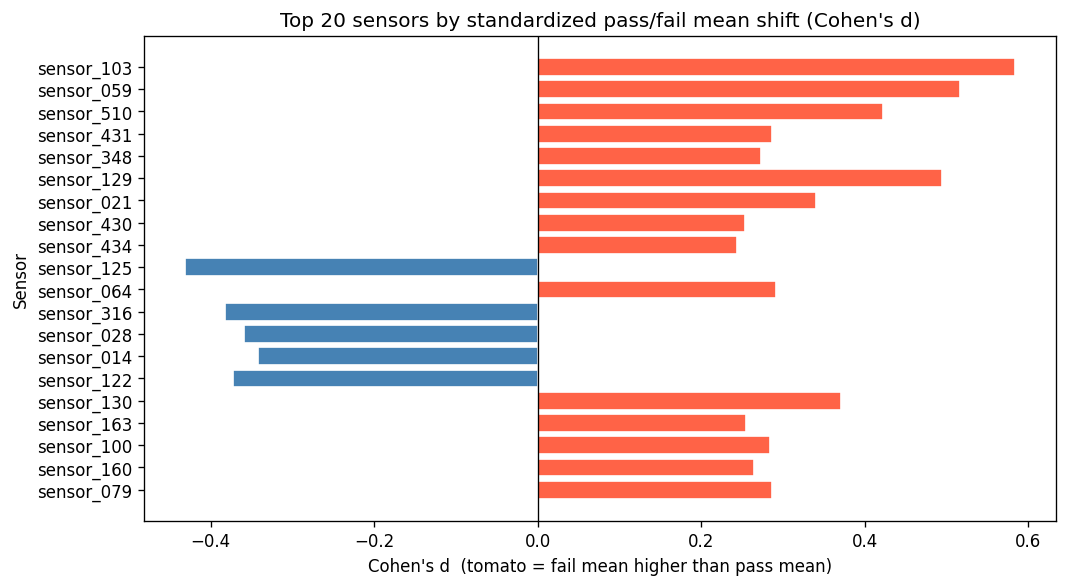

In [6]:
def build_summary(
    features: pd.DataFrame,
    target: pd.Series,
    corr: pd.DataFrame,
) -> pd.DataFrame:
    """Build a per-sensor summary of the standardized pass/fail mean shift.

    Args:
        features: DataFrame of sensor readings, index-aligned with *target*.
        target: Binary series (0 = pass, 1 = fail).
        corr: Output of :func:`compute_correlations`; must contain ``sensor`` and ``r``.

    Returns:
        DataFrame with columns ``sensor``, ``r``, ``mean_pass``, ``mean_fail``,
        ``difference`` (fail − pass), and ``cohens_d`` (difference standardized by
        the pooled standard deviation), sorted by ``abs_r`` descending.
    """
    pass_mask: pd.Series = target == 0
    fail_mask: pd.Series = target == 1

    rows: list[dict[str, object]] = []
    for _, row in corr.iterrows():
        sensor: str = str(row["sensor"])
        passes: pd.Series = features.loc[pass_mask, sensor]
        fails: pd.Series = features.loc[fail_mask, sensor]
        pooled_std: float = float(
            np.sqrt((passes.std() ** 2 + fails.std() ** 2) / 2)
        )
        diff: float = fails.mean() - passes.mean()
        rows.append(
            {
                "sensor": sensor,
                "r": row["r"],
                "mean_pass": passes.mean(),
                "mean_fail": fails.mean(),
                "difference": diff,
                "cohens_d": diff / pooled_std if pooled_std else 0.0,
            }
        )

    return pd.DataFrame(rows)


summary_df: pd.DataFrame = build_summary(df[SENSOR_COLS], TARGET, corr_df)

top20s: pd.DataFrame = summary_df.head(20).copy()

fig, ax = plt.subplots(figsize=(9, 5))
colors: list[str] = ["tomato" if d > 0 else "steelblue" for d in top20s["cohens_d"]]
ax.barh(
    top20s["sensor"][::-1],
    top20s["cohens_d"][::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 20 sensors by standardized pass/fail mean shift (Cohen's d)")
ax.set_xlabel("Cohen's d  (tomato = fail mean higher than pass mean)")
ax.set_ylabel("Sensor")
plt.tight_layout()

## Candidate sensors before SHAP modeling

These predictions are derived from the training-split point-biserial correlations and standardized mean-shift analysis above. Later SHAP global feature-importance and sensor ranking analysis should check each pattern.

- **`sensor_103` and `sensor_059` will rank at the top of SHAP global importance** (`sensor_103`: r = 0.156, the largest |r| and the largest standardized pass/fail shift in the chart above, Cohen's *d* ≈ 0.58; `sensor_059`: r = 0.135, mean-fail ~3× mean-pass, Cohen's *d* ≈ 0.52). They carry the strongest univariate signal in the preprocessed feature set; a tree-based model should assign high SHAP weight to both.

- **`sensor_510`, `sensor_129`, `sensor_431`, `sensor_430`, and `sensor_434` will cluster in the top SHAP features** (r ≈ 0.10–0.13, with clear standardized shifts). Their moderate correlations and distributional separation make them likely high-ranking sensors even if their individual SHAP values are lower than `sensor_103` and `sensor_059`.

- **`sensor_021` will appear in SHAP rankings even though its native scale is hard to read** (r = 0.104, with raw readings in the thousands). Standardizing the shift puts it on the same footing as the other candidates in the chart above, confirming the separation is real rather than a scale artefact.

- **Negatively correlated sensors (`sensor_125`, `sensor_316`, `sensor_028`, `sensor_014`, `sensor_122`) should show negative SHAP contributions** — high sensor values are associated with passing wafers, so the model should push predicted failure probability *down* when these sensors are elevated. Sensor ranking analysis should flag *low* readings of these sensors as risk indicators, not high readings.

- **No single sensor should account for more than ~5–10% of SHAP variance.** The maximum |r| is only 0.156, and the sensor space is still 242 features after preprocessing. Expect a long tail of small SHAP contributions rather than a clean 'top cause'.

- **`sensor_160` and `sensor_163` may rank higher in tree-based SHAP than their |r| suggests** (r ≈ 0.078–0.081, mid-pack univariate signal). Tree models can exploit non-linear threshold effects that point-biserial correlation does not capture.